<a href="https://colab.research.google.com/github/vishnubyneni/MLA0202-MACHINE-LEARNING/blob/main/DBSCAN_ALGORITHM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_excel("/content/DBSCAN_Dataset_2000rows.xlsx")
df

,CustomerID,AnnualIncome_k$,SpendingScore,Age,MonthlyPurchases_$,StoreVisits_monthly,Gender,Region,TrueCluster,DBSCAN_Label,PointType
0,1,58.1,75.3,36,4005,7,Male,South,Cluster 7,NaN,NaN
1,2,17.4,74.0,26,3851,5,Female,West,Cluster 1,NaN,NaN
2,3,87.1,22.9,50,980,3,Male,West,Cluster 5,NaN,NaN
3,4,53.3,49.8,34,2122,5,Female,East,Cluster 3,NaN,NaN
4,5,69.1,43.0,48,1829,2,Female,East,Cluster 4,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,72.5,41.2,53,2176,4,Female,East,Cluster 4,NaN,NaN
1996,1997,71.2,36.4,49,1861,3,Male,South,Cluster 4,NaN,NaN
1997,1998,57.6,61.2,36,3478,5,Male,North,Cluster 3,NaN,NaN
1998,1999,83.1,16.8,55,685,1,Female,South,Cluster 5,NaN,NaN


In [ ]:
df.columns

Index(['CustomerID', 'AnnualIncome_k$', 'SpendingScore', 'Age',
       'MonthlyPurchases_$', 'StoreVisits_monthly', 'Gender', 'Region',
       'TrueCluster', 'DBSCAN_Label', 'PointType'],
      dtype='object')

In [ ]:
columns_to_drop = ['DBSCAN_Label','PointType',"TrueCluster"]
existing_columns = [col for col in columns_to_drop if col in df.columns]
if existing_columns:
    df = df.drop(columns=existing_columns, axis=1)
else:
    print(f"Columns {columns_to_drop} already dropped or never existed.")

Columns ['DBSCAN_Label', 'PointType', 'TrueCluster'] already dropped or never existed.


In [ ]:
df

,CustomerID,AnnualIncome_k$,SpendingScore,Age,MonthlyPurchases_$,StoreVisits_monthly,Gender,Region
0,1,58.1,75.3,36,4005,7,Male,South
1,2,17.4,74.0,26,3851,5,Female,West
2,3,87.1,22.9,50,980,3,Male,West
3,4,53.3,49.8,34,2122,5,Female,East
4,5,69.1,43.0,48,1829,2,Female,East
...,...,...,...,...,...,...,...,...
1995,1996,72.5,41.2,53,2176,4,Female,East
1996,1997,71.2,36.4,49,1861,3,Male,South
1997,1998,57.6,61.2,36,3478,5,Male,North
1998,1999,83.1,16.8,55,685,1,Female,South


In [ ]:
df.columns


Index(['CustomerID', 'AnnualIncome_k$', 'SpendingScore', 'Age',
       'MonthlyPurchases_$', 'StoreVisits_monthly', 'Gender', 'Region'],
      dtype='object')

In [ ]:
df["gender"]=df['Gender'].map({"Male":1,"Female":0})

In [ ]:
df["region"]=pd.factorize(df["Region"])[0]

In [ ]:
df=df.drop(columns=["gender","region","CustomerID","Gender","Region"], errors='ignore')

In [ ]:
df

,AnnualIncome_k$,SpendingScore,Age,MonthlyPurchases_$,StoreVisits_monthly
0,58.1,75.3,36,4005,7
1,17.4,74.0,26,3851,5
2,87.1,22.9,50,980,3
3,53.3,49.8,34,2122,5
4,69.1,43.0,48,1829,2
...,...,...,...,...,...
1995,72.5,41.2,53,2176,4
1996,71.2,36.4,49,1861,3
1997,57.6,61.2,36,3478,5
1998,83.1,16.8,55,685,1


In [ ]:
x=df

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
x_scaled_df=pd.DataFrame(x_scaled,columns=df.columns)
x_scaled_df

,AnnualIncome_k$,SpendingScore,Age,MonthlyPurchases_$,StoreVisits_monthly
0,0.303223,0.822436,0.096230,1.011759,0.750076
1,-1.392505,0.764260,-0.819378,0.879834,0.167493
2,1.511481,-1.522504,1.378083,-1.579629,-0.415091
3,0.103235,-0.318708,-0.086891,-0.601327,0.167493
4,0.761528,-0.623013,1.194961,-0.852327,-0.706383
...,...,...,...,...,...
1995,0.903186,-0.703565,1.652766,-0.555067,-0.123799
1996,0.849022,-0.918368,1.286522,-0.824914,-0.415091
1997,0.282391,0.191450,0.096230,0.560300,0.167493
1998,1.344825,-1.795483,1.835887,-1.832343,-0.997675


In [66]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd

eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [3, 5, 10]

results = []

for eps in eps_values:
    for min_s in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(x_scaled)
        n_clusters=len(set(labels)) - (1 if -1 in labels else 0)
        n_noise=list(labels).count(-1)

        # Remove noise (-1)
        mask = labels != -1
        filtered_data = x_scaled[mask]
        filtered_labels = labels[mask]

        # Check if valid clustering exists
        if len(set(filtered_labels)) > 1:
            sil = silhouette_score(filtered_data, filtered_labels)
            dbi = davies_bouldin_score(filtered_data, filtered_labels)
            ch = calinski_harabasz_score(filtered_data, filtered_labels)
        else:
            sil, dbi, ch = -1, -1, -1  # invalid case

        results.append({
            'eps': eps,
            'min_samples': min_s,
            'silhouette': sil,
            'davies_bouldin': dbi,
            'calinski_harabasz': ch,
            "clusters":n_clusters,
            "noise_points":n_noise
        })

results_df = pd.DataFrame(results)
print(results_df.sort_values(by='silhouette', ascending=False))

    eps  min_samples  silhouette  davies_bouldin  calinski_harabasz  clusters  \
5   0.5           10    0.478981        0.519667        1755.983509         2   
2   0.3           10    0.343512        1.077870        1253.195778        16   
1   0.3            5    0.129172        1.152225         740.584343        27   
0   0.3            3   -0.038886        1.046066         410.166935        47   
3   0.5            3   -1.000000       -1.000000          -1.000000         1   
4   0.5            5   -1.000000       -1.000000          -1.000000         1   
6   0.7            3   -1.000000       -1.000000          -1.000000         1   
7   0.7            5   -1.000000       -1.000000          -1.000000         1   
8   0.7           10   -1.000000       -1.000000          -1.000000         1   
9   1.0            3   -1.000000       -1.000000          -1.000000         1   
10  1.0            5   -1.000000       -1.000000          -1.000000         1   
11  1.0           10   -1.00

<Axes: xlabel='eps', ylabel='clusters'>

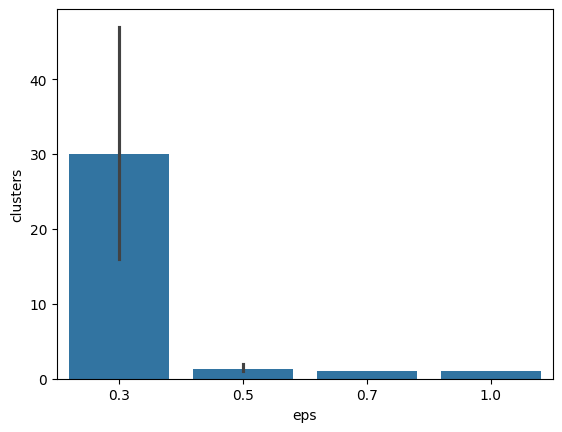

In [67]:
sns.barplot(x='eps', y='clusters', data=df_scaled_results)

<Axes: xlabel='eps', ylabel='noise_points'>

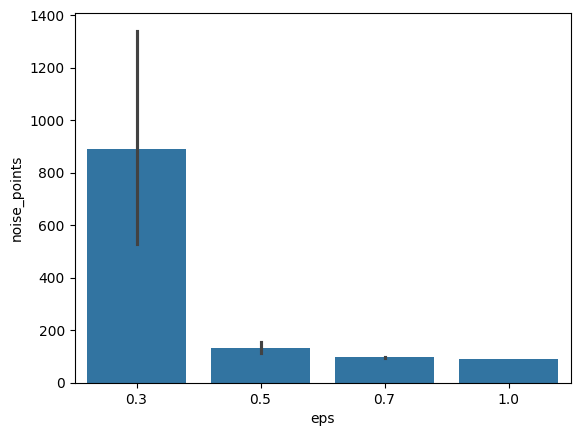

In [68]:
sns.barplot(x='eps', y='noise_points', data=df_scaled_results)

In [70]:
results_df[results_df["silhouette"]>-1]

,eps,min_samples,silhouette,davies_bouldin,calinski_harabasz,clusters,noise_points
0,0.3,3,-0.038886,1.046066,410.166935,47,530
1,0.3,5,0.129172,1.152225,740.584343,27,799
2,0.3,10,0.343512,1.077870,1253.195778,16,1341
5,0.5,10,0.478981,0.519667,1755.983509,2,154


In [72]:
best=results_df.iloc[5:6]

In [77]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=10)
labels = db.fit_predict(x_scaled)

df['Cluster'] = labels
df['Cluster'].value_counts()


,count
Cluster,
0,1549
1,297
-1,154


In [86]:
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

# Based on the DBSCAN clustering with eps=0.5 and min_samples=10, we can draw the following conclusions about the customer segments:
#
# 1. **Cluster 0 (Largest Segment):** This cluster represents a significant portion of the customer base. They tend to have a **moderate annual income** (around $43.65k) but exhibit a **high spending score** (around 64.45), **higher monthly purchases** (around $3205), and moderate store visits. These customers are generally **younger** (average age 31.65). This segment could be characterized as 'Young, High-Spending Customers'.
#
# 2. **Cluster 1 (Second Largest Segment):** This cluster consists of customers with a **higher annual income** (around $87.76k) but a **very low spending score** (around 18.30), **lower monthly purchases** (around $919), and **fewer store visits**. They are typically **older** (average age 49.59). This segment could be labeled as 'Older, High-Income, Low-Spending Customers'.
#
# 3. **Noise Points (Cluster -1):** These are data points that DBSCAN identified as outliers or noise, meaning they do not belong strongly to any specific cluster. They show a mix of characteristics with moderate values across most features, and high `StoreVisits_monthly`, suggesting they are quite diverse and don't fit the patterns of the core clusters.
#
# The PCA plot visually confirms these distinct groupings, showing clear separation between the two main clusters and the scattered noise points, which reinforces the validity of these identified customer segments.

         AnnualIncome_k$  SpendingScore        Age  MonthlyPurchases_$  \
Cluster                                                                  
-1             51.690260      55.621429  39.902597         2657.181818   
 0             43.653260      64.456036  31.648806         3205.716591   
 1             87.761616      18.301684  49.592593          919.292929   

         StoreVisits_monthly  DBSCAN_label  
Cluster                                     
-1                 11.207792     -0.584416  
 0                  4.306649      0.000000  
 1                  1.525253      0.000000  


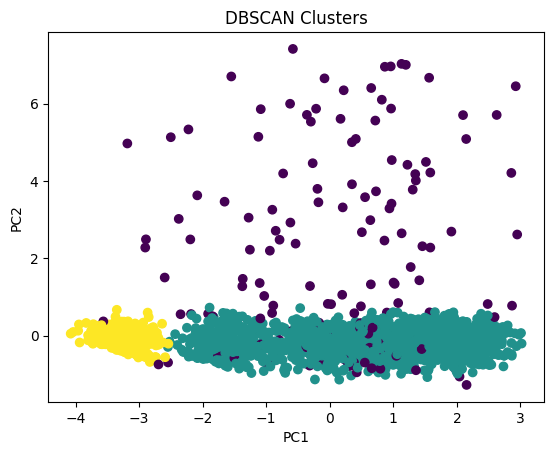

In [85]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("DBSCAN Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()